In [16]:
import torch
from torch import nn
import matplotlib.pyplot as plt
weight=0.7
bias=torch.randn_like(X)*0.1
start=0
end=10
step_size=0.1
X=torch.arange(start,end,step_size).unsqueeze(dim=1)
y=weight*X+bias
train_split=int(len(X)*0.8)


In [ ]:
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
X_train,y_train

In [19]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
    def forward(self,x:torch.tensor):
        return self.weight*x+self.bias

In [20]:
model=LinearRegressionModel()
torch.manual_seed(42)
list(model.parameters())

[Parameter containing:
 tensor([-0.5672], requires_grad=True),
 Parameter containing:
 tensor([-0.5706], requires_grad=True)]

In [21]:
def plots(train_data=X_train,train_label=y_train,
          test_data=X_test,test_label=y_test,
          predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_label,c="b")
    plt.scatter(test_data,test_label,c="r")

    if predictions is not None:
        plt.scatter(test_data,predictions,c="g")
    

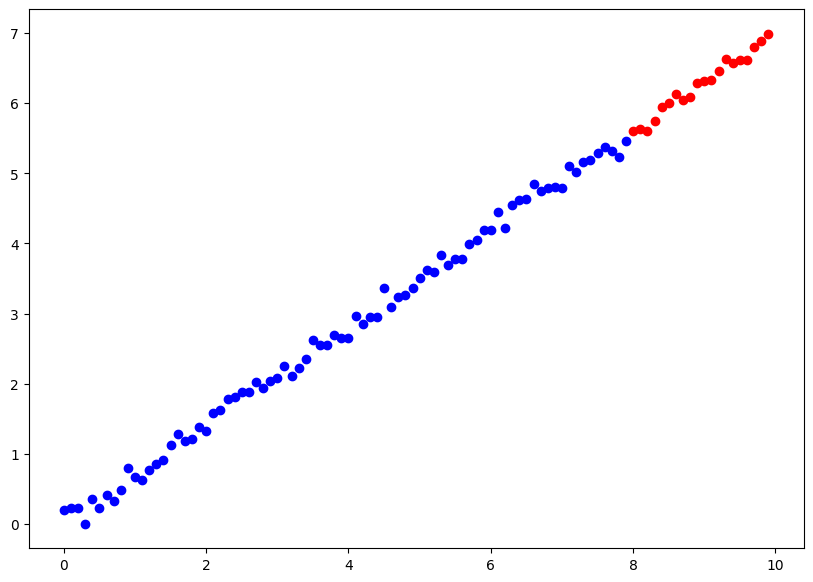

In [22]:
plots()

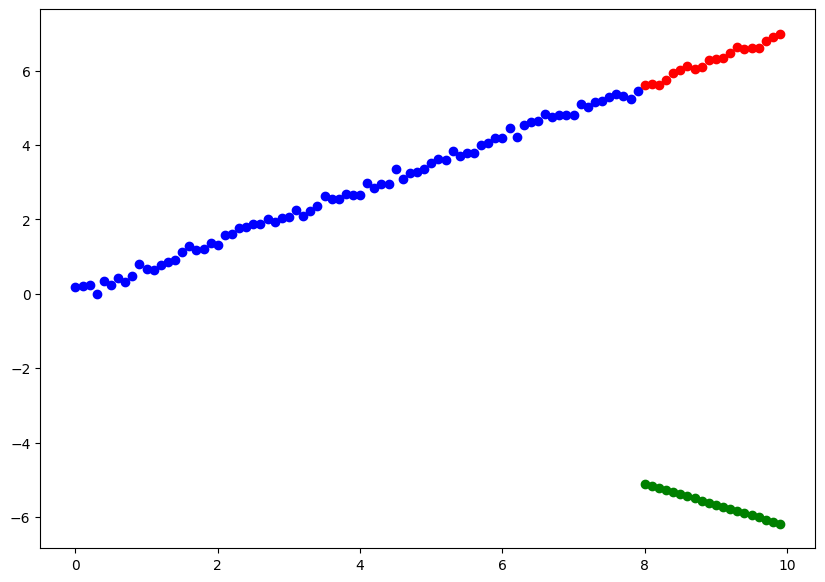

In [23]:
with torch.inference_mode():
    y_preds=model(X_test)
plots(predictions=y_preds)

In [24]:
loss_fn=nn.L1Loss()
loss_fn

L1Loss()

In [25]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [26]:
epochs=200
for epoch in range(epochs):
    model.train()
    y_pred_train=model(X_train)
    loss=loss_fn(y_pred_train,y_train)
    optimizer.zero_grad()
    loss.backward()
    print(f"loss before optimizer step {loss}")
    optimizer.step()

    #for test loss loop
    model.eval()
    with torch.no_grad():
         y_pred_test=model(X_test)
         loss_test=loss_fn(y_pred_test,y_test)
    print(f"loss after optimizer step {loss_test}")
    print(model.state_dict())
    if epoch%2==0:
        print(epoch)

loss before optimizer step 5.582669258117676
loss after optimizer step 11.551637649536133
OrderedDict([('weight', tensor([-0.5277])), ('bias', tensor([-0.5606]))])
0
loss before optimizer step 5.416644096374512
loss after optimizer step 11.188112258911133
OrderedDict([('weight', tensor([-0.4882])), ('bias', tensor([-0.5506]))])
loss before optimizer step 5.250618934631348
loss after optimizer step 10.82458782196045
OrderedDict([('weight', tensor([-0.4487])), ('bias', tensor([-0.5406]))])
2
loss before optimizer step 5.084594249725342
loss after optimizer step 10.461061477661133
OrderedDict([('weight', tensor([-0.4092])), ('bias', tensor([-0.5306]))])
loss before optimizer step 4.918569564819336
loss after optimizer step 10.09753704071045
OrderedDict([('weight', tensor([-0.3697])), ('bias', tensor([-0.5206]))])
4
loss before optimizer step 4.752544403076172
loss after optimizer step 9.734012603759766
OrderedDict([('weight', tensor([-0.3302])), ('bias', tensor([-0.5106]))])
loss before o

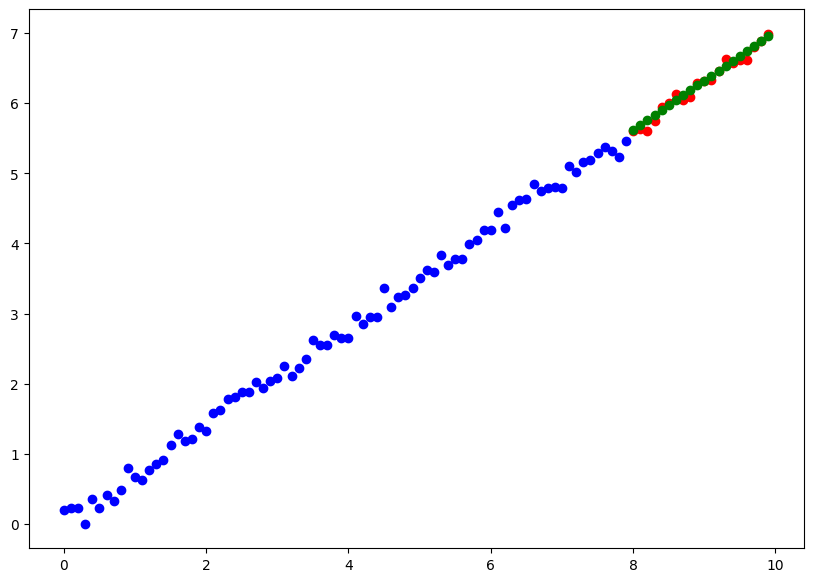

In [27]:
with torch.inference_mode():
    y_pred_la=model(X_test)
plots(predictions=y_pred_la)